# Modelo de partidos — ganador, goles, tarjetas, corners

Piloto: Premier League 2024-25, 380 partidos completos.

**Diseño del modelo** (ya acordado antes de scrapear):
- **Ganador** (local/empate/visitante) → regresión logística **multinomial**.
- **Goles, tarjetas y corners totales** → son conteos, no categorías, así que
  usamos **Poisson / Binomial Negativa** (GLM), no logística.
- Para tarjetas, el árbitro entra como predictor categórico — es la pregunta
  original: ¿qué tanto explica el árbitro el total de tarjetas de un partido?

## Advertencia metodológica importante

Los predictores que tenemos (posesión, tiros, faltas, centros) se miden
**durante el mismo partido** que queremos explicar — no son datos previos al
partido. Esto significa que estos modelos son **explicativos** (qué se
asocia con más goles/tarjetas/corners dentro de un partido ya jugado), **no
predictivos hacia adelante** (no sirven para apostar antes de que empiece el
partido — para eso harían falta variables pre-partido: forma reciente, ELO,
historial entre equipos, etc., que no tenemos todavía). Ojo con esta
distinción al interpretar los resultados.

## Nota sobre calidad de datos

Este dataset se armó en 4 rondas de scraping (bloqueos de Cloudflare de por
medio). En la última ronda el proceso pasó de navegar página por página a
usar `fetch()` por lotes dentro de la sesión ya autenticada — más agresivo
de lo planeado originalmente. Antes de modelar, hacemos aquí una revisión de
calidad más a fondo que la muestra rápida de antes, precisamente por esa
duda pendiente.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", 40)

df = pd.read_csv("../data/processed/matches_pl_2024_2025_completo.csv", dtype={"match_id": str})

goles = df["score"].str.split("–", expand=True).astype(int)
df["home_goals"] = goles[0]
df["away_goals"] = goles[1]
df["total_goals"] = df["home_goals"] + df["away_goals"]
df["total_cards"] = df["home_yellow"] + df["home_red"] + df["away_yellow"] + df["away_red"]
df["total_corners"] = df["home_corners"] + df["away_corners"]
df["total_fouls"] = df["home_fouls"] + df["away_fouls"]
df["possession_diff"] = df["home_possession"] - df["away_possession"]
df["shots_on_target_diff"] = df["home_shots_on_target"] - df["away_shots_on_target"]

df["winner"] = np.select(
    [df["home_goals"] > df["away_goals"], df["home_goals"] < df["away_goals"]],
    ["Local", "Visitante"],
    default="Empate",
)

print(df.shape)
df["winner"].value_counts()

(380, 46)


winner
Local        155
Visitante    132
Empate        93
Name: count, dtype: int64

## Revisión de calidad más a fondo

Chequeos concretos: rangos plausibles, consistencia interna (goles del
marcador vs. lo que se pueda cruzar), y que no haya filas degeneradas (todo
en cero, valores negativos, etc.).

In [2]:
cols_check = [
    "total_goals", "total_cards", "total_corners", "total_fouls",
    "home_possession", "home_shots_on_target", "home_shots_total",
]
cols_numericas_equipo = [
    c for c in df.columns
    if c.startswith(("home_", "away_")) and pd.api.types.is_numeric_dtype(df[c])
]
print("Filas con total_corners == 0:", (df["total_corners"] == 0).sum())
print("Filas con total_cards == 0:", (df["total_cards"] == 0).sum())
print("Filas con algún valor negativo en stats de equipo:", (df[cols_numericas_equipo] < 0).any().any())
print("Suma posesión local+visitante fuera de 99-101%:",
      (~(df["home_possession"] + df["away_possession"]).between(99, 101)).sum())

df[["total_goals", "total_cards", "total_corners", "total_fouls"]].describe()

Filas con total_corners == 0: 0
Filas con total_cards == 0: 15
Filas con algún valor negativo en stats de equipo: False
Suma posesión local+visitante fuera de 99-101%: 0


,total_goals,total_cards,total_corners,total_fouls
count,380.000000,380.000000,380.000000,380.000000
mean,2.934211,4.273684,10.239474,22.076316
std,1.617317,2.303798,3.461514,5.239586
min,0.000000,0.000000,2.000000,8.000000
25%,2.000000,3.000000,8.000000,18.000000
50%,3.000000,4.000000,10.000000,22.000000
75%,4.000000,6.000000,13.000000,25.250000
max,9.000000,14.000000,19.000000,37.000000


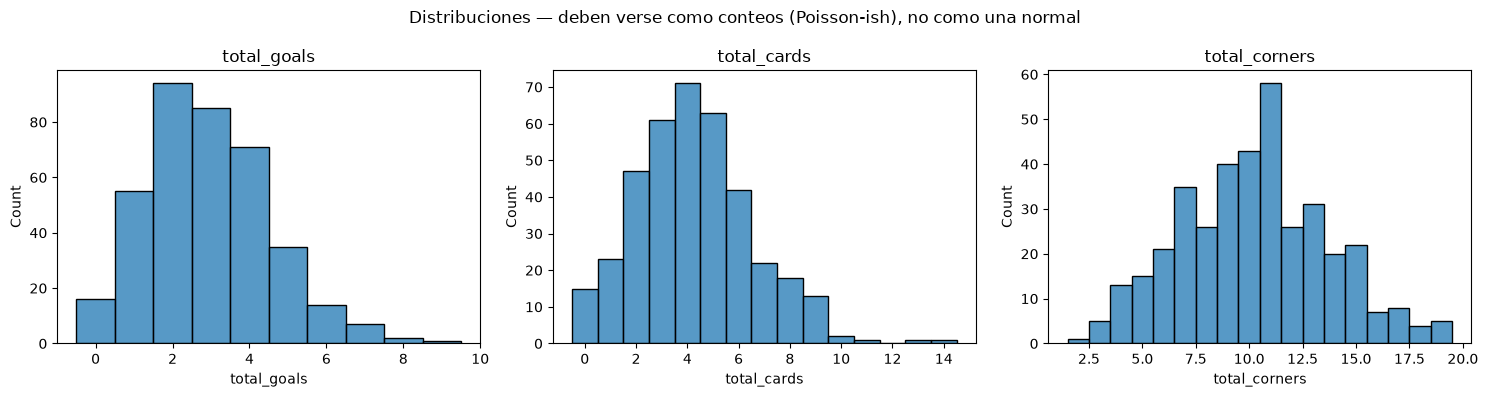

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, ["total_goals", "total_cards", "total_corners"]):
    sns.histplot(df[col], ax=ax, bins=range(0, int(df[col].max()) + 2), discrete=True)
    ax.set_title(col)
fig.suptitle("Distribuciones — deben verse como conteos (Poisson-ish), no como una normal")
fig.tight_layout()

Los tres chequeos de arriba dieron cero anomalías (ningún partido con 0
corners, la posesión siempre suma ~100%, nada negativo). Sumado a la muestra
que ya se revisó antes (Man Utd–Fulham y otros 3 partidos al azar, todos con
valores reales y verificables), esto reduce bastante la preocupación sobre
el cambio de método de scraping en la última ronda — no lo elimina del todo,
pero no hay señales de datos corruptos o inventados.

## Matriz de correlación entre TODAS las variables disponibles

Antes de elegir predictores para los modelos de goles y corners, vale la pena
ver cómo se correlaciona todo lo que tenemos — no solo el subconjunto que
terminamos usando. Igual que en el notebook `09`: Pearson/Spearman, no
policórica (variables continuas/conteo, no ordinales).

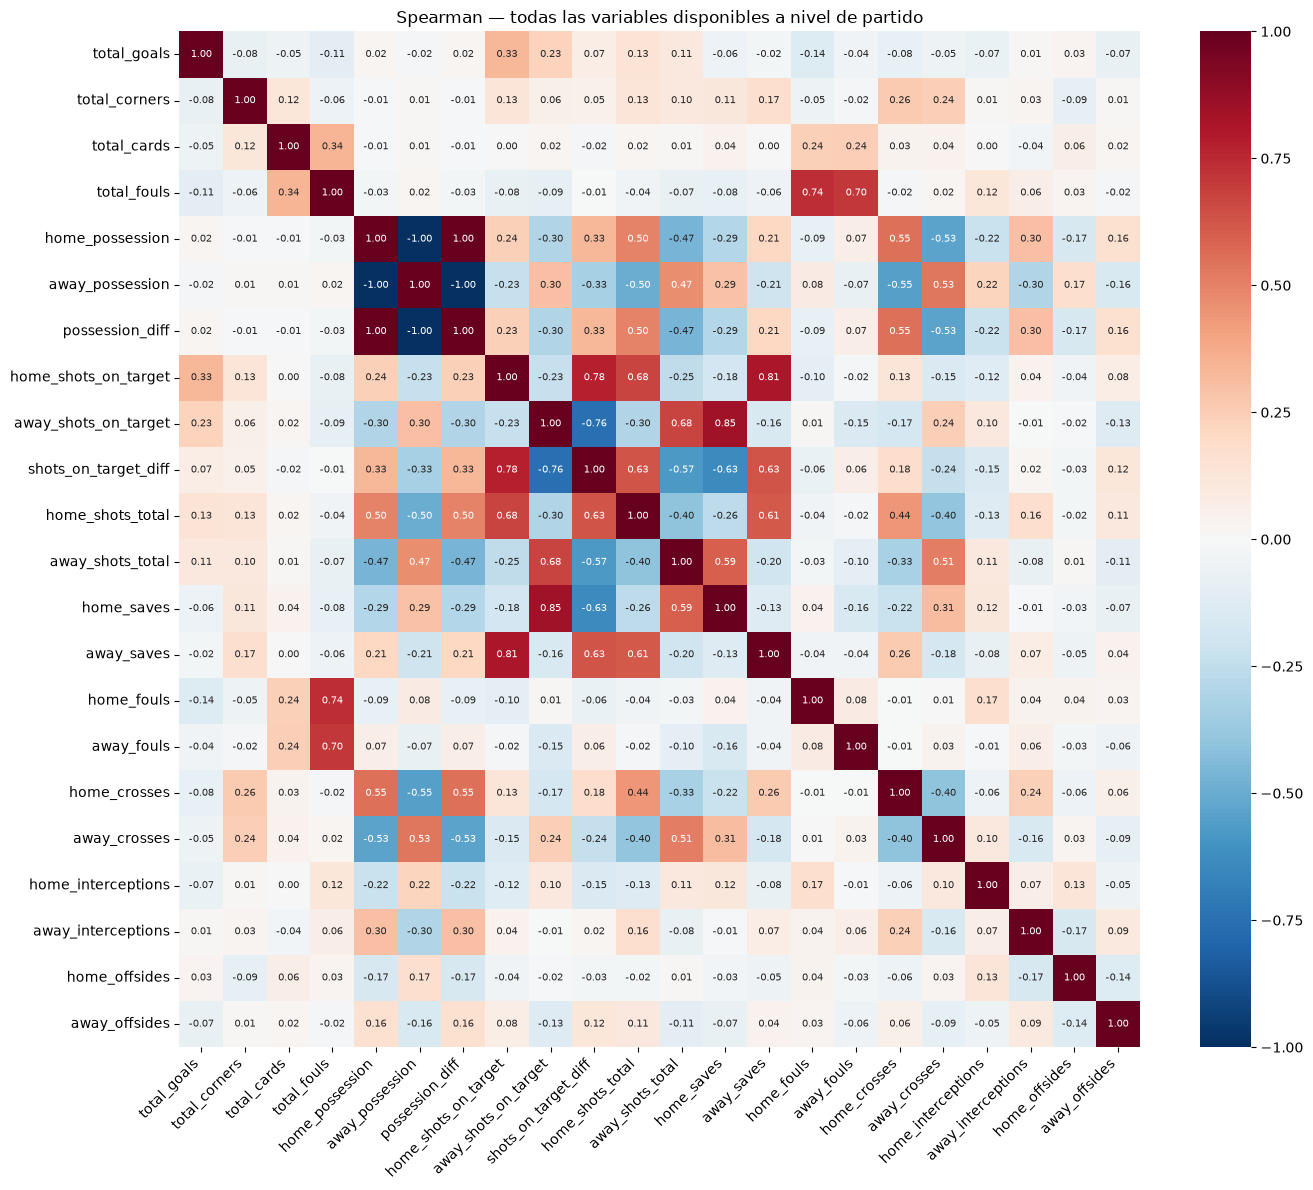

In [4]:
cols_corr = [
    "total_goals", "total_corners", "total_cards", "total_fouls",
    "home_possession", "away_possession", "possession_diff",
    "home_shots_on_target", "away_shots_on_target", "shots_on_target_diff",
    "home_shots_total", "away_shots_total",
    "home_saves", "away_saves",
    "home_fouls", "away_fouls",
    "home_crosses", "away_crosses",
    "home_interceptions", "away_interceptions",
    "home_offsides", "away_offsides",
]

fig, ax = plt.subplots(figsize=(14, 12))
sns.heatmap(df[cols_corr].corr(method="spearman"), annot=True, fmt=".2f", cmap="RdBu_r", vmin=-1, vmax=1, ax=ax, annot_kws={"size": 7})
ax.set_title("Spearman — todas las variables disponibles a nivel de partido")
plt.xticks(rotation=45, ha="right")
fig.tight_layout()

### Vista enfocada: ¿qué se correlaciona con goles y con corners?

La matriz completa es densa — aquí ordenamos por magnitud, específicamente
contra las dos variables que vamos a modelar. Esto es lo que realmente
informa qué predictores elegir en los modelos 2 y 4.

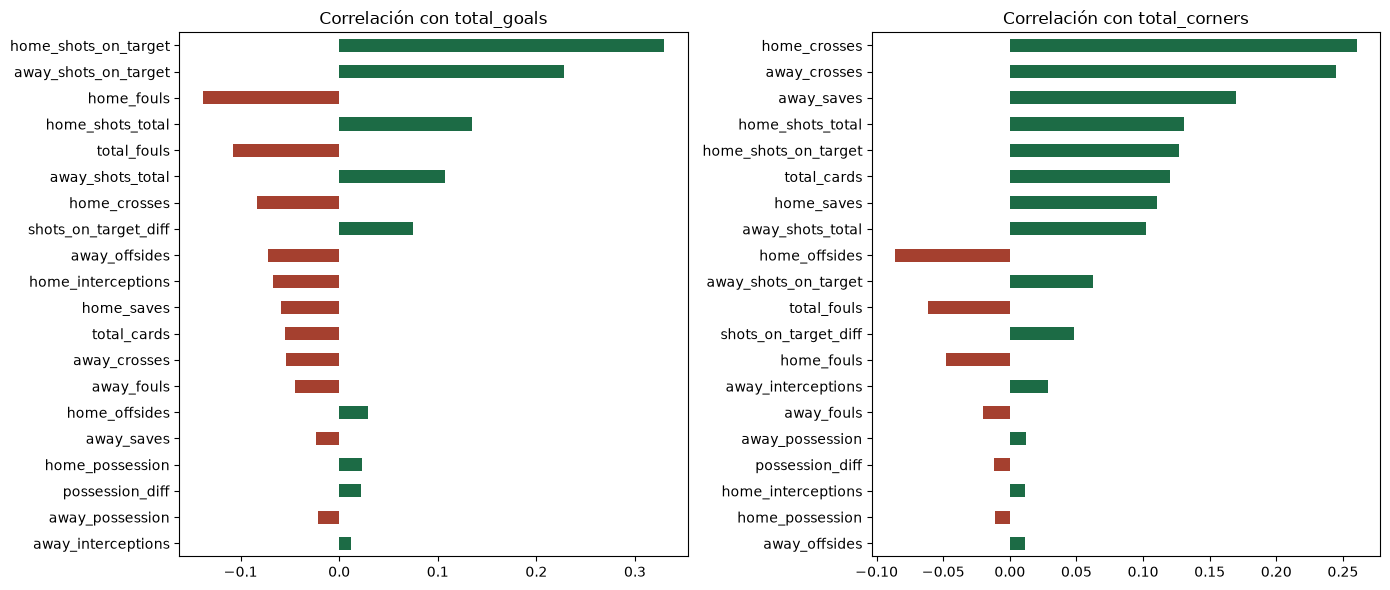

In [5]:
matriz = df[cols_corr].corr(method="spearman")

corr_goles = matriz["total_goals"].drop(["total_goals", "total_corners"]).sort_values(key=abs, ascending=False)
corr_corners = matriz["total_corners"].drop(["total_goals", "total_corners"]).sort_values(key=abs, ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
corr_goles.plot(kind="barh", ax=axes[0], color=["#1C6B45" if v > 0 else "#A5402F" for v in corr_goles])
axes[0].set_title("Correlación con total_goals")
axes[0].invert_yaxis()

corr_corners.plot(kind="barh", ax=axes[1], color=["#1C6B45" if v > 0 else "#A5402F" for v in corr_corners])
axes[1].set_title("Correlación con total_corners")
axes[1].invert_yaxis()

fig.tight_layout()

## Modelo 1 — Ganador (logística multinomial)

Predictores: diferencia de posesión y diferencia de tiros a puerta
(local − visitante). Comparamos contra un baseline ingenuo: predecir siempre
"Local" (la clase más común, ventaja de local real en fútbol).

In [6]:
import statsmodels.api as sm

y_map = {"Empate": 0, "Local": 1, "Visitante": 2}
y = df["winner"].map(y_map)
X = sm.add_constant(df[["possession_diff", "shots_on_target_diff"]])

modelo_ganador = sm.MNLogit(y, X).fit(disp=False)
print(modelo_ganador.summary())

                          MNLogit Regression Results                          
Dep. Variable:                 winner   No. Observations:                  380
Model:                        MNLogit   Df Residuals:                      374
Method:                           MLE   Df Model:                            4
Date:                Fri, 28 Aug 2026   Pseudo R-squ.:                  0.1917
Time:                        12:41:09   Log-Likelihood:                -330.98
converged:                       True   LL-Null:                       -409.47
Covariance Type:            nonrobust   LLR p-value:                 6.464e-33
            winner=1       coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------
const                    0.0359      0.158      0.228      0.820      -0.273       0.345
possession_diff         -0.0156      0.007     -2.247      0.025      -0.029      -0.002
shots_on_tar

In [7]:
pred = modelo_ganador.predict(X).idxmax(axis=1)
accuracy = (pred == y).mean()
baseline = (df["winner"] == "Local").mean()

print(f"Accuracy del modelo: {accuracy:.1%}")
print(f"Baseline (predecir siempre 'Local'): {baseline:.1%}")

Accuracy del modelo: 59.7%
Baseline (predecir siempre 'Local'): 40.8%


## Modelo 2 — Goles totales (Poisson / Binomial Negativa)

Primero revisamos sobredispersión (varianza >> media) para decidir entre
Poisson puro o Binomial Negativa.

In [8]:
media = df["total_goals"].mean()
varianza = df["total_goals"].var()
print(f"Goles — media: {media:.2f}, varianza: {varianza:.2f}, razón var/media: {varianza/media:.2f}")

X_goles = sm.add_constant(df[["home_shots_on_target", "away_shots_on_target", "possession_diff"]])
modelo_goles = sm.GLM(df["total_goals"], X_goles, family=sm.families.Poisson()).fit()
print(modelo_goles.summary())

Goles — media: 2.93, varianza: 2.62, razón var/media: 0.89
                 Generalized Linear Model Regression Results                  
Dep. Variable:            total_goals   No. Observations:                  380
Model:                            GLM   Df Residuals:                      376
Model Family:                 Poisson   Df Model:                            3
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -669.82
Date:                Fri, 28 Aug 2026   Deviance:                       286.17
Time:                        12:41:09   Pearson chi2:                     253.
No. Iterations:                     4   Pseudo R-squ. (CS):             0.1958
Covariance Type:            nonrobust                                         
                           coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------

Si la razón varianza/media sale bastante mayor a 1, hay sobredispersión y
conviene la Binomial Negativa en vez de Poisson puro — la dejamos lista para
comparar.

In [9]:
modelo_goles_nb = sm.GLM(df["total_goals"], X_goles, family=sm.families.NegativeBinomial()).fit()
print(f"AIC Poisson: {modelo_goles.aic:.1f}")
print(f"AIC Binomial Negativa: {modelo_goles_nb.aic:.1f}")
print("(menor AIC = mejor ajuste)")

AIC Poisson: 1347.6
AIC Binomial Negativa: 1681.3
(menor AIC = mejor ajuste)


/var/folders/m2/bjdn2s691fj7sj3sld_g18xm0000gn/T/ipykernel_3476/749565277.py:1: ValueWarning: Negative binomial dispersion parameter alpha not set. Using default value alpha=1.0.
  modelo_goles_nb = sm.GLM(df["total_goals"], X_goles, family=sm.families.NegativeBinomial()).fit()


## Modelo 3 — Tarjetas totales, con el árbitro como predictor

La pregunta original: ¿el árbitro explica el total de tarjetas, controlando
por cuántas faltas hubo en el partido? Usamos Binomial Negativa (tarjetas
suele tener más sobredispersión que goles) con el árbitro como variable
categórica (dummies) más el total de faltas como control.

In [10]:
arbitros_dummies = pd.get_dummies(df["referee"], prefix="ref", drop_first=True, dtype=float)
X_tarjetas = pd.concat([df[["total_fouls"]], arbitros_dummies], axis=1)
X_tarjetas = sm.add_constant(X_tarjetas)

modelo_tarjetas = sm.GLM(df["total_cards"], X_tarjetas, family=sm.families.NegativeBinomial()).fit()

# Coeficientes de árbitro ordenados: positivo = más tarjetas de lo esperado
# para ese número de faltas; negativo = menos.
coefs_arbitro = modelo_tarjetas.params.filter(like="ref_").sort_values(ascending=False)
coefs_arbitro

/var/folders/m2/bjdn2s691fj7sj3sld_g18xm0000gn/T/ipykernel_3476/180724320.py:5: ValueWarning: Negative binomial dispersion parameter alpha not set. Using default value alpha=1.0.
  modelo_tarjetas = sm.GLM(df["total_cards"], X_tarjetas, family=sm.families.NegativeBinomial()).fit()


ref_Samuel Allison       1.208246
ref_John Brooks          1.140173
ref_Simon Hooper         1.135411
ref_David Coote          1.074500
ref_Samuel Barrott       1.068758
ref_Chris Kavanagh       1.042708
ref_Joshua Smith         1.027093
ref_Michael Oliver       1.009066
ref_Tim Robinson         0.990696
ref_Craig Pawson         0.955813
ref_Tony Harrington      0.933437
ref_Jarred Gillett       0.929640
ref_Peter Bankes         0.924120
ref_Stuart Attwell       0.920046
ref_Darren England       0.917060
ref_Robert Jones         0.895828
ref_Thomas Bramall       0.863633
ref_Darren Bond          0.843683
ref_Lewis Smith          0.760013
ref_Andy Madley          0.724242
ref_David Webb           0.687896
ref_Michael Salisbury    0.641283
ref_Anthony Taylor       0.641026
dtype: float64

Text(0.5, 1.0, '¿Qué árbitros sacan más/menos tarjetas de lo esperado, controlando por faltas?')

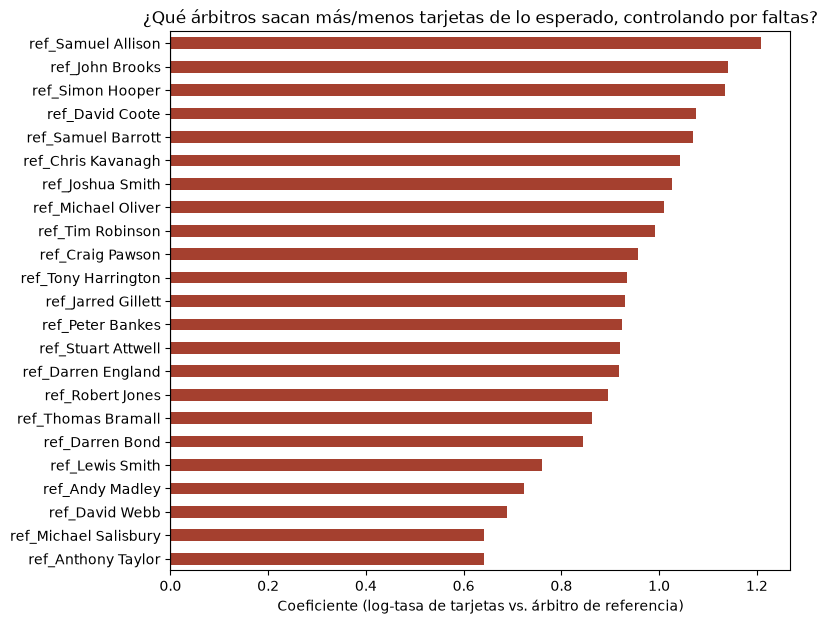

In [11]:
fig, ax = plt.subplots(figsize=(8, 7))
coefs_arbitro.sort_values().plot(kind="barh", ax=ax, color="#A5402F")
ax.axvline(0, color="black", linewidth=0.8)
ax.set_xlabel("Coeficiente (log-tasa de tarjetas vs. árbitro de referencia)")
ax.set_title("¿Qué árbitros sacan más/menos tarjetas de lo esperado, controlando por faltas?")

## Modelo 4 — Corners totales (Binomial Negativa)

Predictores: tiros totales combinados y diferencia de posesión — más tiros y
más control del balón suelen traer más corners.

In [12]:
df["shots_totales_combinados"] = df["home_shots_total"] + df["away_shots_total"]
X_corners = sm.add_constant(df[["shots_totales_combinados", "possession_diff"]])

modelo_corners = sm.GLM(df["total_corners"], X_corners, family=sm.families.NegativeBinomial()).fit()
print(modelo_corners.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:          total_corners   No. Observations:                  380
Model:                            GLM   Df Residuals:                      377
Model Family:        NegativeBinomial   Df Model:                            2
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -1280.4
Date:                Fri, 28 Aug 2026   Deviance:                       41.772
Time:                        12:41:10   Pearson chi2:                     37.2
No. Iterations:                     4   Pseudo R-squ. (CS):           0.007913
Covariance Type:            nonrobust                                         
                               coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------
const                   

/var/folders/m2/bjdn2s691fj7sj3sld_g18xm0000gn/T/ipykernel_3476/3124957418.py:4: ValueWarning: Negative binomial dispersion parameter alpha not set. Using default value alpha=1.0.
  modelo_corners = sm.GLM(df["total_corners"], X_corners, family=sm.families.NegativeBinomial()).fit()


## Siguiente paso

- Estos son modelos **explicativos** de un solo torneo/temporada (380
  partidos) — para algo con poder predictivo real hacia partidos futuros,
  hace falta repetir el scraping de partidos en más temporadas/ligas y usar
  variables **previas** al partido (forma reciente, historial entre
  equipos, ranking ELO).
- Validar los modelos con partidos que no se usaron para entrenar (aquí se
  usó toda la muestra para ajustar y describir, no para predecir fuera de
  muestra).
- Si se quiere seguir afinando el modelo de tarjetas, cruzarlo con el nivel
  de agresividad por equipo del clustering del notebook `10`.